# Mean Filtering

บทนี้อธิบายการกรองภาพด้วย **mean filter** หรือ **average filter** ซึ่งเป็นตัวกรองเชิงพื้นที่ (spatial filter) แบบพื้นฐาน ใช้สำหรับลดสัญญาณรบกวนในภาพโดยแทนค่าพิกเซลด้วยค่าเฉลี่ยของพิกเซลรอบข้าง

หัวข้อที่เรียนใน notebook นี้

- แนวคิดของ spatial filtering
- หลักการของ mean filtering
- การใช้ `cv2.blur`
- การใช้ `cv2.filter2D` กับ kernel ค่าเฉลี่ย
- การเขียน mean filter แบบวนลูปเองเพื่อให้เห็นขั้นตอน
- ผลของขนาด kernel ต่อภาพที่ได้


## 1. Spatial Filtering คืออะไร

**Filtering** คือเทคนิคสำหรับปรับปรุงหรือเปลี่ยนแปลงภาพ เพื่อให้ภาพเหมาะกับการใช้งานมากขึ้น เช่น ทำให้ภาพเรียบขึ้น ลด noise ทำให้ภาพคมขึ้น หรือเน้นขอบของวัตถุ ตัวอย่างงานประมวลผลภาพที่ใช้ filtering ได้แก่ **smoothing**, **sharpening** และ **edge enhancement**

**Spatial filtering** คือการกรองภาพในโดเมนเชิงพื้นที่ โดยค่าพิกเซลแต่ละตำแหน่งในภาพผลลัพธ์จะคำนวณจากค่าพิกเซลในบริเวณรอบตำแหน่งเดียวกันของภาพต้นฉบับ บริเวณรอบพิกเซลนี้เรียกว่า **neighborhood** หรือ **window**

ตัวอย่าง window ขนาด `3 x 3`

```text
p1 p2 p3
p4 p5 p6
p7 p8 p9
```

ถ้ากำลังคำนวณค่าของพิกเซลกลาง `p5` ตัวกรองจะนำค่าของพิกเซลใน window นี้มาคำนวณตามวิธีที่กำหนด เช่น ค่าเฉลี่ย ค่ามัธยฐาน หรือผลรวมถ่วงน้ำหนัก แล้วแทนค่าพิกเซลกลางด้วยผลลัพธ์ใหม่


## 2. หลักการของ Mean Filtering

Mean filtering แทนค่าพิกเซลด้วย **ค่าเฉลี่ย** ของพิกเซลในบริเวณรอบข้าง รวมทั้งตัวพิกเซลเองด้วย

สำหรับ window ขนาด `3 x 3`

```text
ค่าใหม่ของพิกเซลกลาง = (p1 + p2 + ... + p9) / 9
```

เขียนเป็น kernel ได้ดังนี้

```text
1/9  1/9  1/9
1/9  1/9  1/9
1/9  1/9  1/9
```

ข้อดี

- ลด noise แบบสุ่มได้ดีในระดับหนึ่ง
- แนวคิดง่าย เหมาะสำหรับเรียนรู้ convolution/filtering
- คำนวณได้เร็วเมื่อใช้ฟังก์ชันจาก library

ข้อจำกัด

- ทำให้ภาพเบลอ โดยเฉพาะบริเวณขอบวัตถุ
- ไม่เหมาะที่สุดสำหรับ salt-and-pepper noise เมื่อเทียบกับ median filter
- kernel ขนาดใหญ่ขึ้นจะลด noise มากขึ้น แต่ภาพจะเบลอมากขึ้นด้วย


## 3. Import Library


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


## 4. ฟังก์ชันสำหรับแสดงภาพ

ใช้ `matplotlib.pyplot` แบบพื้นฐาน เพื่อให้นักศึกษาเห็นขั้นตอนชัดเจน ไม่ตั้งค่า style ระดับสูง และไม่ใช้ `plt.rcParams`


In [3]:
def show_image(image, title):
    plt.figure(figsize=(5, 5))
    plt.imshow(image, cmap="gray", vmin=0, vmax=255)
    plt.title(title)
    plt.axis("off")
    plt.show()


def show_images(images, titles):
    count = len(images)
    plt.figure(figsize=(4 * count, 4))

    for i in range(count):
        plt.subplot(1, count, i + 1)
        plt.imshow(images[i], cmap="gray", vmin=0, vmax=255)
        plt.title(titles[i])
        plt.axis("off")

    plt.show()


## 5. อ่านภาพแบบ Grayscale

ตัวอย่างนี้ใช้ภาพที่มี noise อยู่แล้ว เพื่อให้เห็นผลของ mean filter ได้ชัดเจน

การอ่านไฟล์ภาพควรตรวจสอบว่าอ่านสำเร็จหรือไม่ เพราะ `cv2.imread` จะคืนค่า `None` เมื่อ path ผิดหรือไฟล์เสีย ตัวอย่างนี้ใช้ `try/except` และ `raise` แบบตรงไปตรงมา


ชนิดข้อมูล: uint8
ขนาดภาพ: (512, 512)


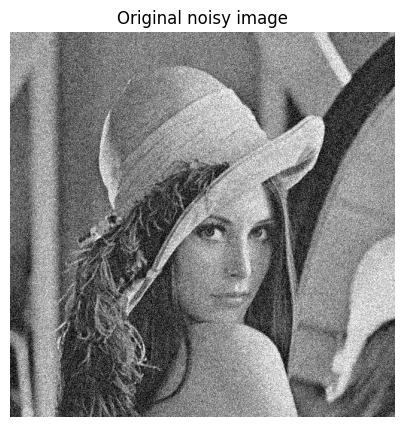

In [4]:
image_path = "./images/lena_noise_512.png"

try:
    gray = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if gray is None:
        raise FileNotFoundError("ไม่พบไฟล์รูปภาพ: " + image_path)

except Exception as error:
    print("เกิดข้อผิดพลาดในการอ่านไฟล์รูปภาพ")
    raise error

print("ชนิดข้อมูล:", gray.dtype)
print("ขนาดภาพ:", gray.shape)

show_image(gray, "Original noisy image")


## 6. วิธีที่ 1: ใช้ `cv2.blur`

`cv2.blur` เป็นฟังก์ชันสำเร็จรูปสำหรับ mean filtering โดยกำหนดขนาด kernel เป็น `(k, k)`

ตัวอย่างนี้ใช้ kernel ขนาด `3 x 3`


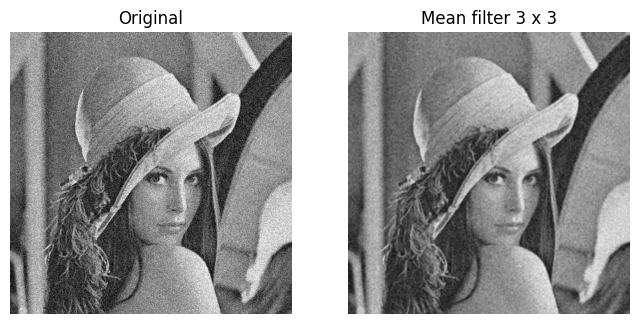

In [5]:
k = 3
mean_cv = cv2.blur(gray, (k, k))

show_images(
    [gray, mean_cv],
    ["Original", "Mean filter 3 x 3"]
)


## 7. วิธีที่ 2: ใช้ `cv2.filter2D` กับ Mean Kernel

Mean filter สามารถมองเป็นการทำ convolution ด้วย kernel ที่สมาชิกทุกตัวมีค่าเท่ากัน และผลรวมของสมาชิกทั้งหมดเท่ากับ `1`

สำหรับ kernel ขนาด `k x k`

```text
kernel = matrix of ones / (k * k)
```


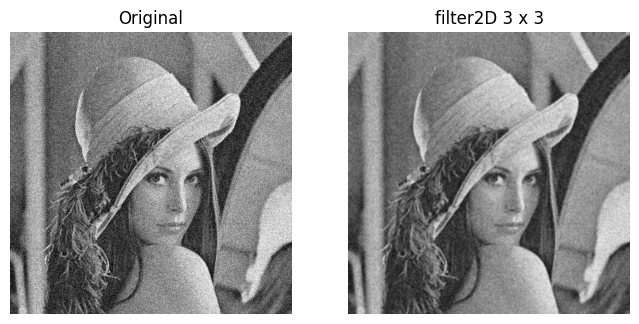

In [6]:
def mean_filter_with_kernel(image, kernel):
    result = cv2.filter2D(image, -1, kernel)
    return result.astype(np.uint8)


k = 3
kernel_3x3 = np.ones((k, k), dtype=np.float32) / (k * k)
mean_filter2d = mean_filter_with_kernel(gray, kernel_3x3)

show_images(
    [gray, mean_filter2d],
    ["Original", "filter2D 3 x 3"]
)


## 8. วิธีที่ 3: เขียน Mean Filter แบบวนลูปเอง

ฟังก์ชันนี้เขียนเพื่อการเรียนการสอน ให้เห็นขั้นตอนการเลื่อน window ไปทีละตำแหน่ง

เพื่อให้ code สั้นและเข้าใจง่าย ขอบภาพจะคงค่าเดิมไว้ ส่วนพิกเซลด้านในจะคำนวณด้วยค่าเฉลี่ยของ window


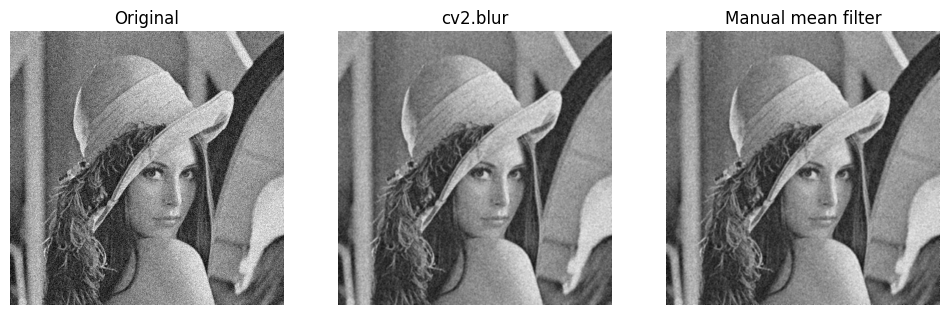

In [7]:
def mean_filter_manual(image, k):
    border = k // 2
    height, width = image.shape
    output = image.copy()

    for row in range(border, height - border):
        for col in range(border, width - border):
            area = image[
                row - border : row + border + 1,
                col - border : col + border + 1
            ]
            output[row, col] = int(np.mean(area))

    return output


mean_manual = mean_filter_manual(gray, 3)

show_images(
    [gray, mean_cv, mean_manual],
    ["Original", "cv2.blur", "Manual mean filter"]
)


## 9. เปรียบเทียบผลของขนาด Kernel

ขนาด kernel มีผลโดยตรงต่อภาพที่ได้

- `3 x 3` ลด noise เล็กน้อยและยังรักษารายละเอียดไว้ได้ค่อนข้างดี
- `5 x 5` ภาพเรียบขึ้น แต่รายละเอียดเริ่มลดลง
- `9 x 9` ภาพเรียบมากขึ้น แต่ขอบและรายละเอียดจะเบลอมากขึ้น


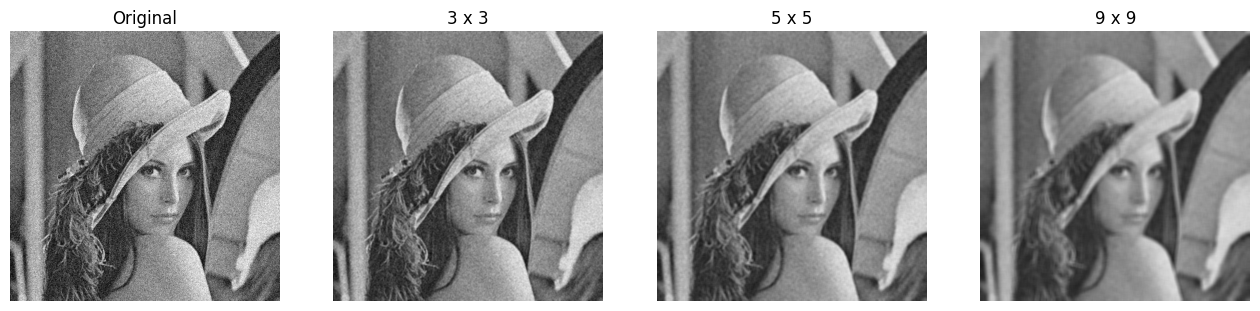

In [8]:
mean_3 = cv2.blur(gray, (3, 3))
mean_5 = cv2.blur(gray, (5, 5))
mean_9 = cv2.blur(gray, (9, 9))

show_images(
    [gray, mean_3, mean_5, mean_9],
    ["Original", "3 x 3", "5 x 5", "9 x 9"]
)


## 10. สรุป

Mean filtering เป็นตัวกรองพื้นฐานที่ช่วยลด noise โดยแทนค่าพิกเซลด้วยค่าเฉลี่ยของพิกเซลรอบข้าง แนวคิดสำคัญคือการใช้ window หรือ kernel เลื่อนไปทั่วภาพ

สิ่งที่ควรจำ

- kernel ของ mean filter ต้องหารด้วยจำนวนสมาชิกทั้งหมด เช่น `3 x 3` ต้องหารด้วย `9`
- kernel ขนาดใหญ่ทำให้ภาพเรียบขึ้น แต่ทำให้รายละเอียดและขอบภาพเบลอมากขึ้น
- `cv2.blur` ใช้ง่ายที่สุดสำหรับ mean filter
- `cv2.filter2D` เหมาะเมื่อเราต้องการเห็นหรือกำหนด kernel เอง
- การเขียนวนลูปเองช่วยให้เข้าใจหลักการ แต่ช้ากว่าฟังก์ชันจาก library
